In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/tuberculosis-trends-global-and-regional-insights/Tuberculosis_Trends.csv


In [2]:
df = pd.read_csv('/kaggle/input/tuberculosis-trends-global-and-regional-insights/Tuberculosis_Trends.csv')

## EDA

In [3]:
df.head()

,Country,Region,Income_Level,Year,TB_Cases,TB_Deaths,TB_Incidence_Rate,TB_Mortality_Rate,TB_Treatment_Success_Rate,Drug_Resistant_TB_Cases,...,GDP_Per_Capita,Health_Expenditure_Per_Capita,Urban_Population_Percentage,Malnutrition_Prevalence,Smoking_Prevalence,TB_Doctors_Per_100K,TB_Hospitals_Per_Million,Access_To_Health_Services,BCG_Vaccination_Coverage,HIV_Testing_Coverage
0,Indonesia,Asia,Upper-Middle,2002,14128,3846,150.58,18.99,54.52,3977,...,25516,3180,50.49,28.84,22.90,4.10,15.46,52.38,95.87,88.39
1,Brazil,North America,Lower-Middle,2017,1069,342,167.80,44.20,88.19,4179,...,26300,5529,24.06,28.65,33.79,8.18,3.06,46.95,63.78,35.60
2,Nigeria,South America,High,2006,2473,6316,285.77,6.52,64.55,4961,...,30771,1703,81.77,38.69,6.63,2.26,4.95,40.88,68.91,77.81
3,Russia,Africa,Lower-Middle,2014,36090,6420,146.46,24.86,69.77,4012,...,35730,8354,42.19,20.38,15.00,8.33,13.68,62.20,71.14,84.91
4,Indonesia,Europe,Upper-Middle,2020,33538,4910,56.87,10.52,64.57,2342,...,38391,8024,64.97,39.28,18.00,6.60,4.35,53.88,55.11,49.89


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        3000 non-null   object 
 1   Region                         3000 non-null   object 
 2   Income_Level                   3000 non-null   object 
 3   Year                           3000 non-null   int64  
 4   TB_Cases                       3000 non-null   int64  
 5   TB_Deaths                      3000 non-null   int64  
 6   TB_Incidence_Rate              3000 non-null   float64
 7   TB_Mortality_Rate              3000 non-null   float64
 8   TB_Treatment_Success_Rate      3000 non-null   float64
 9   Drug_Resistant_TB_Cases        3000 non-null   int64  
 10  HIV_CoInfected_TB_Cases        3000 non-null   int64  
 11  Population                     3000 non-null   int64  
 12  GDP_Per_Capita                 3000 non-null   i

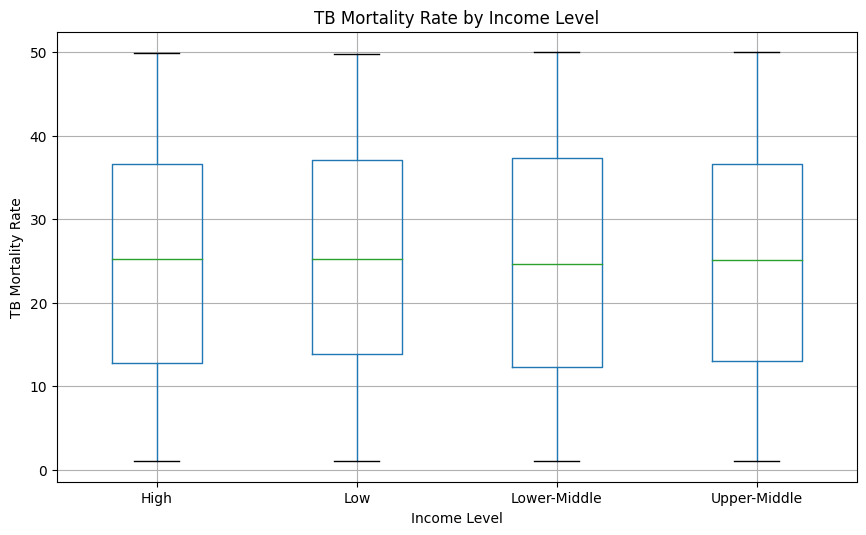

In [5]:
import matplotlib.pyplot as plt

df.boxplot(column='TB_Mortality_Rate', by='Income_Level', figsize=(10, 6))
plt.title('TB Mortality Rate by Income Level')
plt.xlabel('Income Level')
plt.ylabel('TB Mortality Rate')
plt.suptitle('')
plt.show()

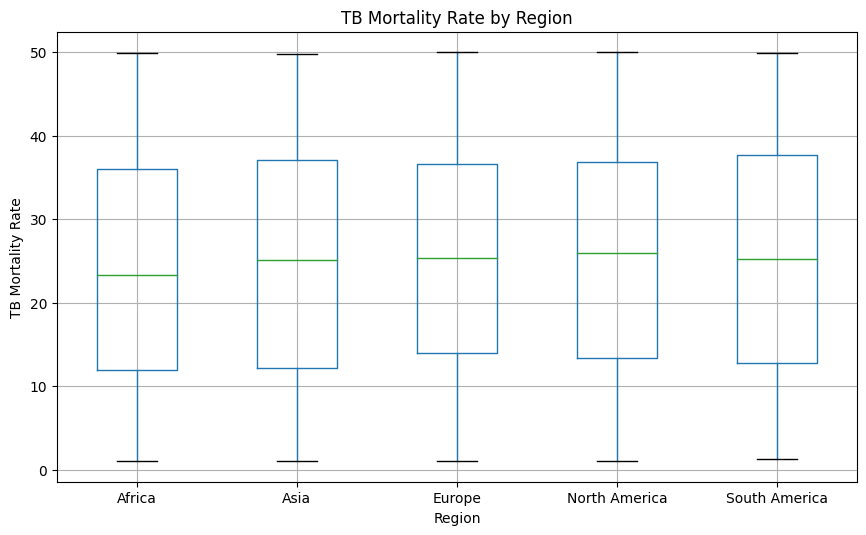

In [6]:
df.boxplot(column='TB_Mortality_Rate', by='Region', figsize=(10, 6))
plt.title('TB Mortality Rate by Region')
plt.xlabel('Region')
plt.ylabel('TB Mortality Rate')
plt.suptitle('')
plt.show()

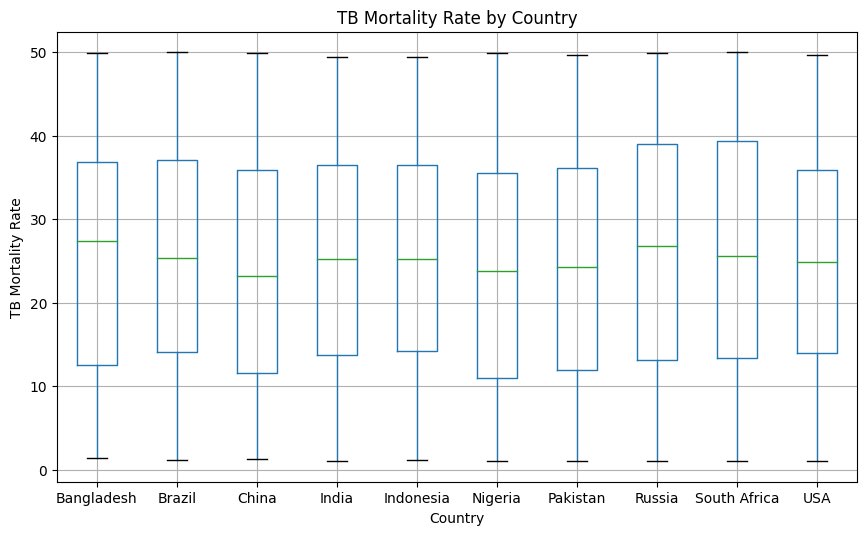

In [7]:
df.boxplot(column='TB_Mortality_Rate', by='Country', figsize=(10, 6))
plt.title('TB Mortality Rate by Country')
plt.xlabel('Country')
plt.ylabel('TB Mortality Rate')
plt.suptitle('')
plt.show()

The obvious difference between TB mortality rate is among countries. Find out more about country groups.

In [8]:
df.drop(['Region','Income_Level'],axis=1,inplace=True)

In [9]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

df_avg = df.groupby('Year')['TB_Mortality_Rate'].mean().reset_index()
df_country_avg = df.groupby(['Country', 'Year'])['TB_Mortality_Rate'].mean().reset_index()
fig = make_subplots(rows=1, cols=2, subplot_titles=('TB Mortality Rate Over Time', 'TB Mortality Rate by Country'))
fig.add_trace(go.Scatter(x=df_avg['Year'], y=df_avg['TB_Mortality_Rate'], mode='lines', name='Average TB Mortality Rate'),
              row=1, col=1)
for country in df_country_avg['Country'].unique():
    country_data = df_country_avg[df_country_avg['Country'] == country]
    fig.add_trace(go.Scatter(x=country_data['Year'], y=country_data['TB_Mortality_Rate'], mode='lines', name=country),
                  row=1, col=2)
fig.update_layout(title_text="TB Mortality Rate Analysis", showlegend=False)
fig.show()


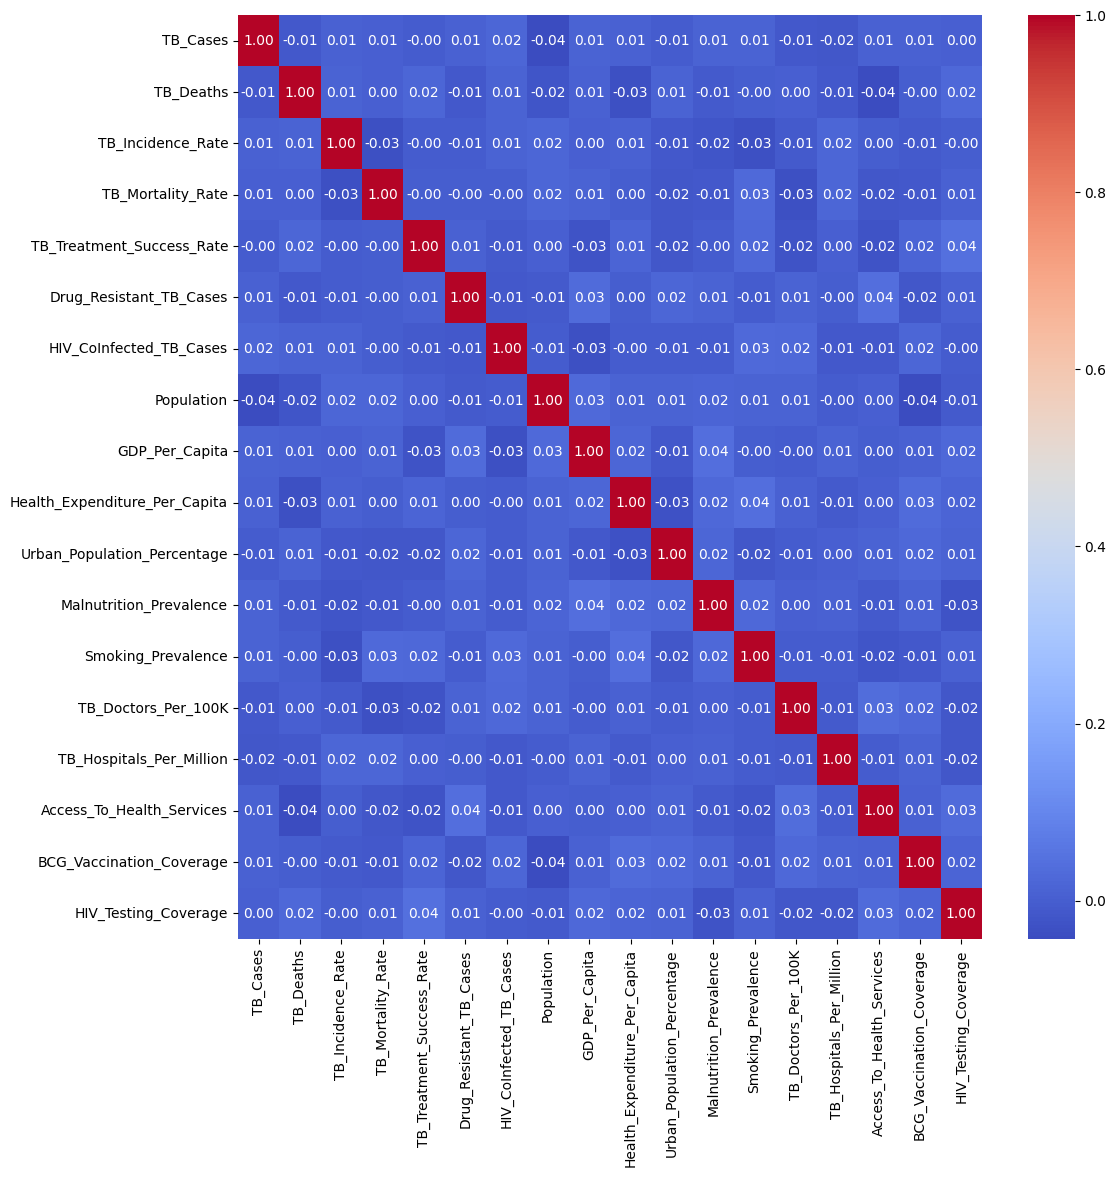

In [10]:
import seaborn as sns

plt.figure(figsize=(12,12))
sns.heatmap(df.drop(['Year','Country'],axis=1).corr(),cmap='coolwarm',annot=True,fmt=".2f")
plt.show()

Due to the high correlations between features, the Variance Inflation Factor (VIF) was calculated to assess multicollinearity. Features with a VIF greater than 10 were considered for removal.

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = df.drop('Country',axis=1).columns
vif_data["VIF"] = [variance_inflation_factor(df.drop('Country',axis=1).values, i) for i in range(len(df.drop('Country',axis=1).columns))]

print(vif_data[vif_data['VIF']>10])

                      feature         VIF
0                        Year  124.974229
5   TB_Treatment_Success_Rate   31.782466
16  Access_To_Health_Services   11.525880
17   BCG_Vaccination_Coverage   29.075766


### Data preprocessing

In [12]:
df.drop(['Year','TB_Treatment_Success_Rate','Access_To_Health_Services','BCG_Vaccination_Coverage'],axis=1,inplace=True)

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df_encoded = pd.get_dummies(df, columns=['Country'], drop_first=True)

X = df_encoded.drop(columns=['TB_Mortality_Rate'])
y = df_encoded['TB_Mortality_Rate']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=39)

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb

model = RandomForestRegressor()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"RMSE: {rmse:.2f}")

RMSE: 14.38
